In [ ]:
# ==========================================
# PROJETO: CLASSIFICAÇÃO DE QUALIDADE DE VINHOS
# ==========================================

# Importando todas as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

# ==========================================
# PASSO 1: COMPREENSÃO DO PROBLEMA E CARGA DE DADOS
# ==========================================
print("--- PASSO 1: Carregando e Estruturando os Dados ---")

# Carregando o dataset
df = pd.read_csv('C:\\Users\\Victor\\Documents\\FIAP\\Wine_Quality_Classification\\data\\winequality-red.csv') 

# Traduzindo as colunas para o português
traducao_colunas = {
    'fixed acidity': 'acidez_fixa',
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'acucar_residual',
    'chlorides': 'cloretos',
    'free sulfur dioxide': 'dioxido_enxofre_livre',
    'total sulfur dioxide': 'dioxido_enxofre_total',
    'density': 'densidade',
    'pH': 'ph',
    'sulphates': 'sulfatos',
    'alcohol': 'teor_alcoolico',
    'quality': 'qualidade'
}
df = df.rename(columns=traducao_colunas)

# Transformação da variável alvo em classificação binária (1 = Alta, 0 = Baixa/Média)
df['alta_qualidade'] = df['qualidade'].apply(lambda x: 1 if x >= 7 else 0)

# Descartando a coluna 'qualidade' original

print("Variável alvo 'alta_qualidade' criada com sucesso!\n")
print(df['alta_qualidade'].value_counts())

--- PASSO 1: Carregando e Estruturando os Dados ---
Variável alvo 'alta_qualidade' criada com sucesso!

alta_qualidade
0    984
1    159
Name: count, dtype: int64


--- PASSO 2: Análise Exploratória (EDA) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   acidez_fixa            1143 non-null   float64
 1   acidez_volatil         1143 non-null   float64
 2   acido_citrico          1143 non-null   float64
 3   acucar_residual        1143 non-null   float64
 4   cloretos               1143 non-null   float64
 5   dioxido_enxofre_livre  1143 non-null   float64
 6   dioxido_enxofre_total  1143 non-null   float64
 7   densidade              1143 non-null   float64
 8   ph                     1143 non-null   float64
 9   sulfatos               1143 non-null   float64
 10  teor_alcoolico         1143 non-null   float64
 11  qualidade              1143 non-null   int64  
 12  Id                     1143 non-null   int64  
 13  alta_qualidade         1143 non-null   int64  
dtypes: float64(1

C:\Users\Victor\AppData\Local\Temp\ipykernel_19312\3903301769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='qualidade', data=df, palette='viridis')


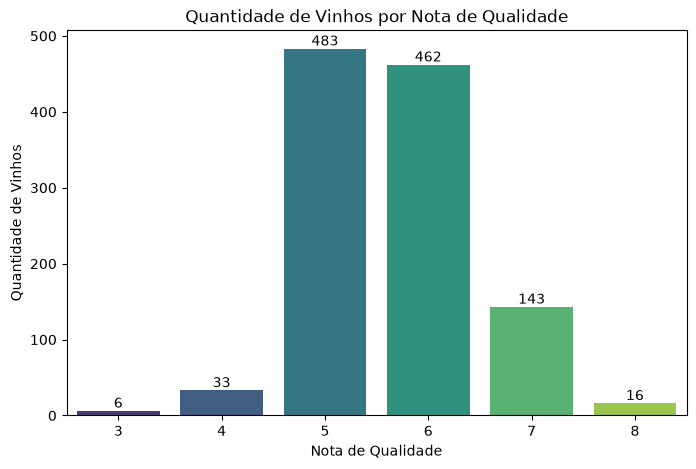

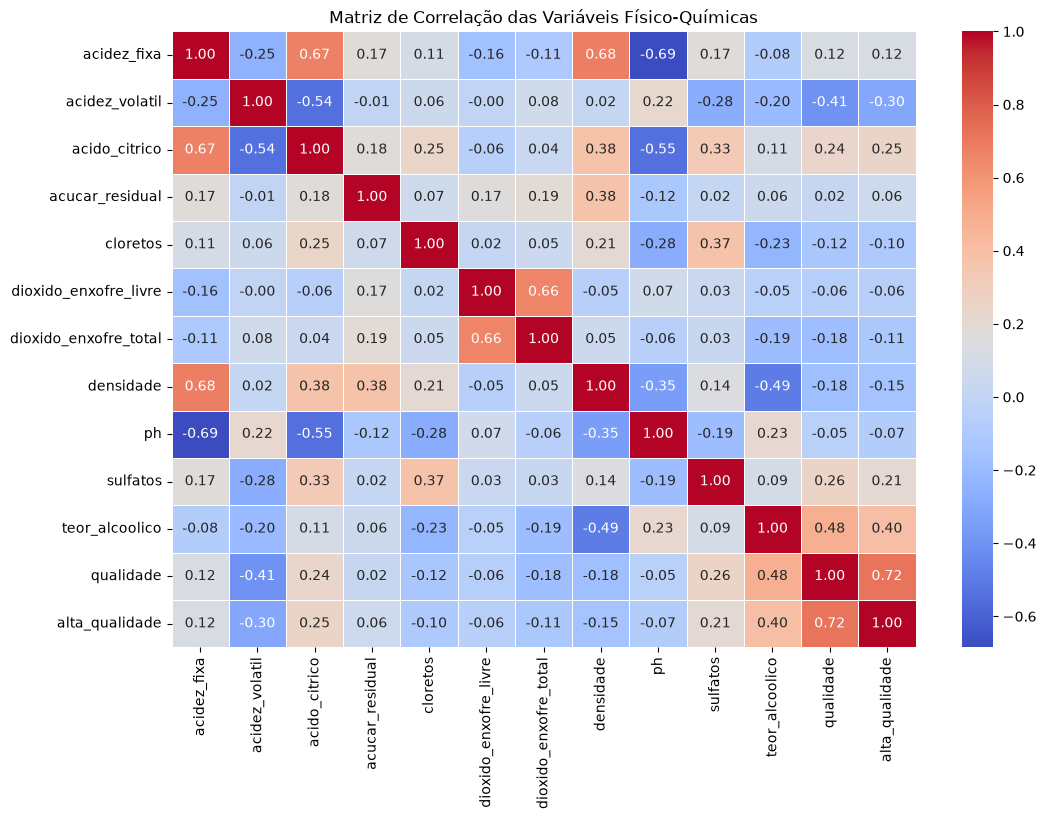

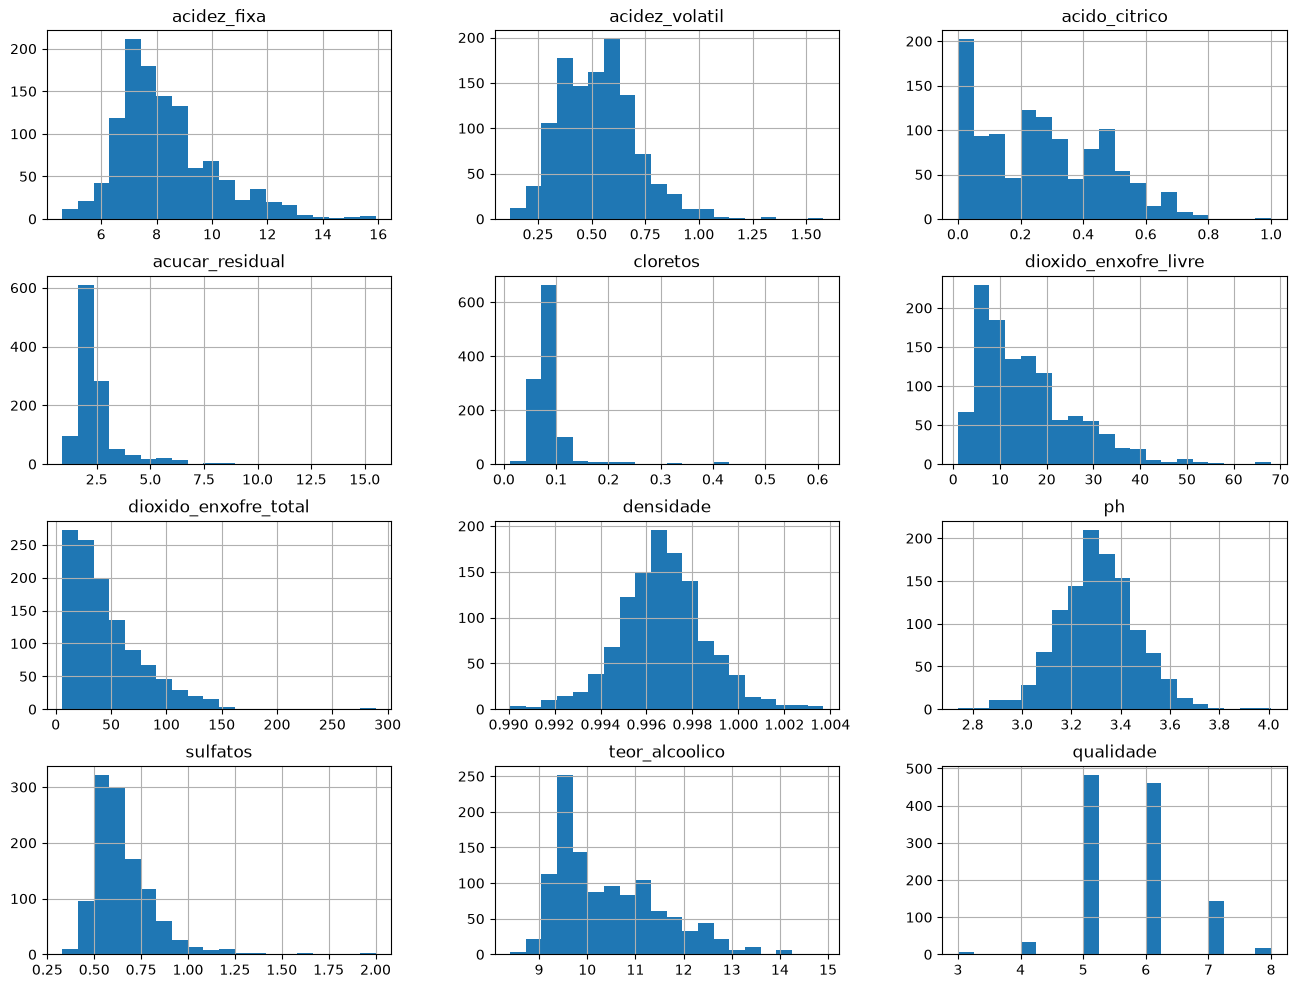

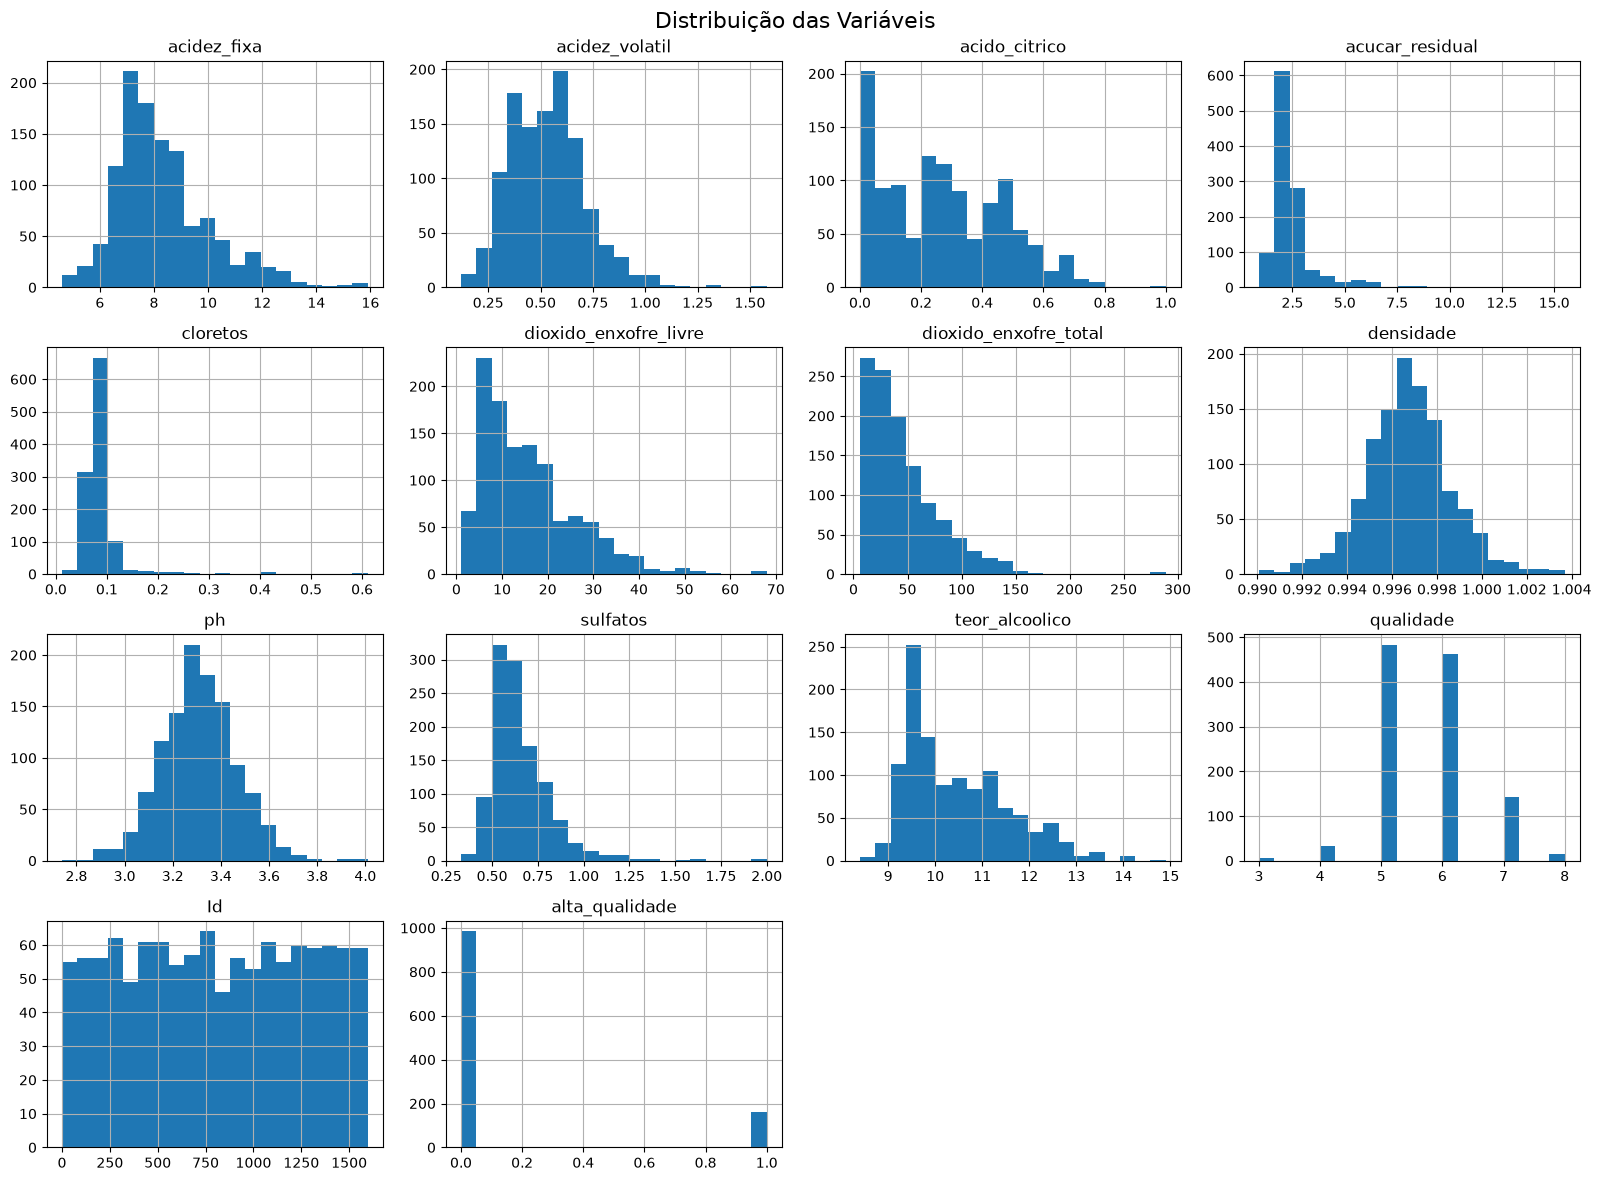

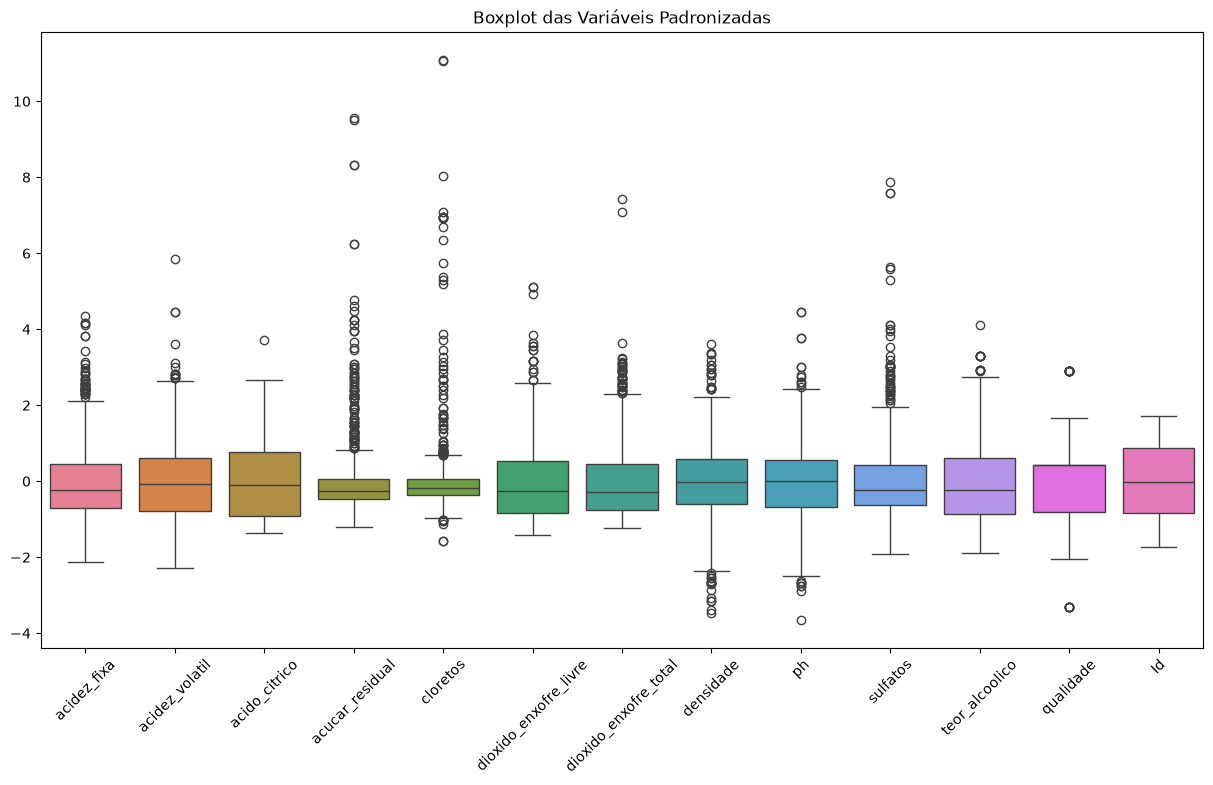

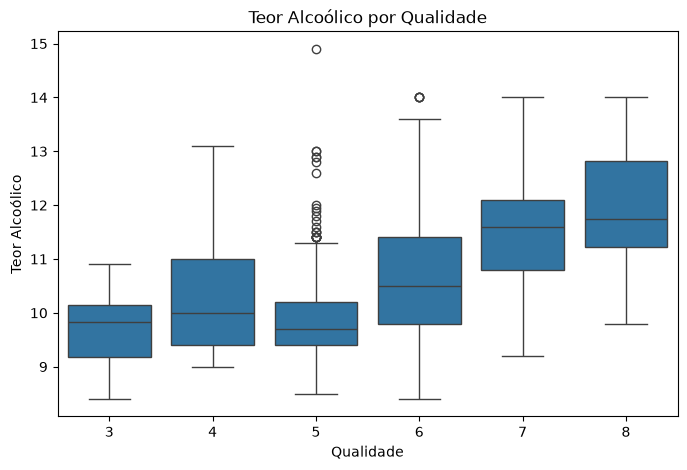

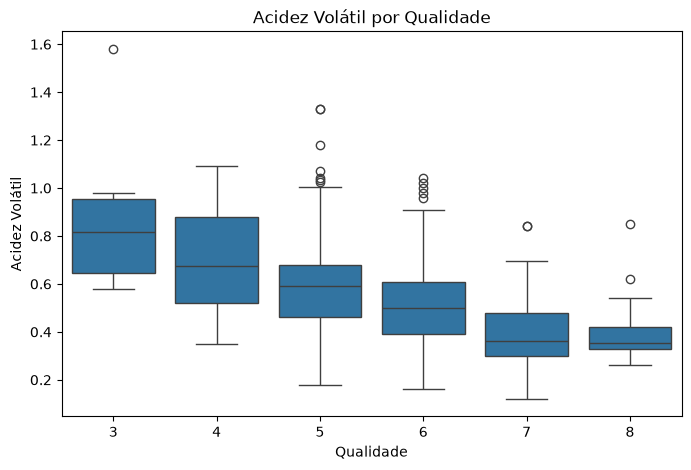

In [29]:
print("--- PASSO 2: Análise Exploratória (EDA) ---")

df.info()

#Gráfico 1: Quantidade de vinhos por nota de qualidade
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='qualidade', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Quantidade de Vinhos por Nota de Qualidade')
plt.xlabel('Nota de Qualidade')
plt.ylabel('Quantidade de Vinhos')
plt.show()

# Gráfico 2: Matriz de Correlação para identificar influência das variáveis
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['Id']).corr(), 
annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Físico-Químicas')
plt.show()

# Gráfico 2: Matriz de Correlação para identificar influência das variáveis
df.drop(columns=['Id', 'alta_qualidade']).hist(figsize=(16,12), bins=20)
df.hist(figsize=(16,12), bins=20)
plt.suptitle('Distribuição das Variáveis', fontsize=16)
plt.tight_layout()
plt.show()
scaler = StandardScaler()
df_padronizado = pd.DataFrame(
    scaler.fit_transform(df.drop(columns=['alta_qualidade'])),
    columns=df.drop(columns=['alta_qualidade']).columns
)

plt.figure(figsize=(15,8))
sns.boxplot(data=df_padronizado)
plt.xticks(rotation=45)
plt.title("Boxplot das Variáveis Padronizadas")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='qualidade', y='teor_alcoolico', data=df)
plt.title('Teor Alcoólico por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Teor Alcoólico')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='qualidade', y='acidez_volatil', data=df)
plt.title('Acidez Volátil por Qualidade')
plt.xlabel('Qualidade')
plt.ylabel('Acidez Volátil')
plt.show()

In [9]:
print("--- PASSO 3: Pré-processamento ---")

# 1. Tratamento de dados faltantes (remover nulos)
df = df.dropna()

# 2. Feature Engineering: Criando a taxa de enxofre livre ativo
df['taxa_enxofre_livre'] = df['dioxido_enxofre_livre'] / df['dioxido_enxofre_total']

# 3. Separação entre variáveis preditoras (X) e a variável alvo (y)
X = df.drop('alta_qualidade', axis=1)
y = df['alta_qualidade']

# 4. Divisão em Treino e Teste (com stratify para manter a proporção das classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Padronização das Escalas (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Engineering aplicada.")
print(f"Dados padronizados. Treino: {X_train_scaled.shape[0]} amostras | Teste: {X_test_scaled.shape[0]} amostras.")

--- PASSO 3: Pré-processamento ---
Feature Engineering aplicada.
Dados padronizados. Treino: 914 amostras | Teste: 229 amostras.


In [10]:
print("--- PASSO 4: Treinando os Modelos ---")

# Modelo 1: Regressão Logística (Baseline)
# Utilizamos class_weight='balanced' para compensar a minoria de vinhos premium
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (Modelo Avançado Não-Linear)
# Também utilizamos pesos balanceados
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

print("Modelos treinados com sucesso!")

--- PASSO 4: Treinando os Modelos ---
Modelos treinados com sucesso!


In [11]:

# ==========================================
# PASSO 5: AVALIAÇÃO DOS MODELOS
# ==========================================

print("--- PASSO 5: Avaliação e Comparação ---")

# Extraindo as previsões (0 ou 1) e as probabilidades (%)
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)
prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]
prob_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

# Função para imprimir os resultados padronizados
def relatorio_completo(nome, y_real, y_pred, probs):
    print(f"\n==== {nome} ====")
    print(f"Acurácia Geral: {accuracy_score(y_real, y_pred):.4f}")
    print(f"ROC-AUC Score:  {roc_auc_score(y_real, probs):.4f}") 
    print("Relatório de Classificação:")
    print(classification_report(y_real, y_pred, target_names=['Comum (0)', 'Premium (1)']))

# Exibindo os relatórios comparativos
relatorio_completo("Regressão Logística", y_test, y_pred_lr, prob_lr)
relatorio_completo("Random Forest", y_test, y_pred_rf, prob_rf)


--- PASSO 5: Avaliação e Comparação ---

==== Regressão Logística ====
Acurácia Geral: 0.7991
ROC-AUC Score:  0.8772
Relatório de Classificação:
              precision    recall  f1-score   support

   Comum (0)       0.94      0.82      0.88       197
 Premium (1)       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229


==== Random Forest ====
Acurácia Geral: 0.9127
ROC-AUC Score:  0.9137
Relatório de Classificação:
              precision    recall  f1-score   support

   Comum (0)       0.95      0.95      0.95       197
 Premium (1)       0.69      0.69      0.69        32

    accuracy                           0.91       229
   macro avg       0.82      0.82      0.82       229
weighted avg       0.91      0.91      0.91       229



--- PASSO 6: Interpretação de Resultados (Random Forest) ---


C:\Users\jessi\AppData\Local\Temp\ipykernel_10872\944165619.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=df_importancias, palette='mako')


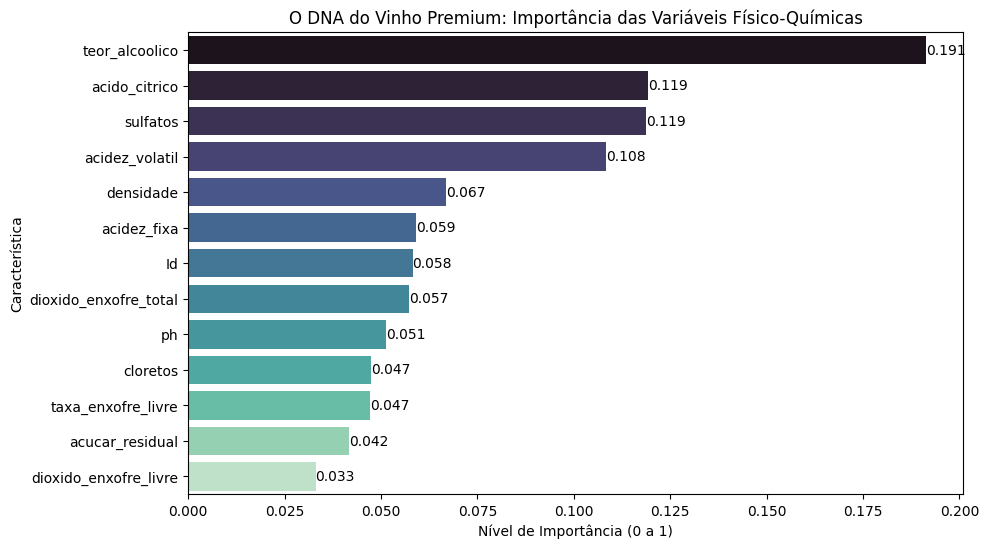

In [ ]:
print("--- PASSO 6: Interpretação de Resultados (Random Forest) ---")

# Extraindo os pesos das variáveis que o Random Forest aprendeu
importancias = modelo_rf.feature_importances_

# Organizando em um DataFrame
df_importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Plotando o gráfico de Importância
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variavel', data=df_importancias, palette='mako')
plt.title('O DNA do Vinho Premium: Importância das Variáveis Físico-Químicas')
plt.xlabel('Nível de Importância (0 a 1)')
plt.ylabel('Característica')

# Adicionando os números exatos no final de cada barra para um visual executivo
for index, value in enumerate(df_importancias['Importancia']):
    plt.text(value, index, f'{value:.3f}', va='center', fontsize=10)

plt.show()

